<a href="https://colab.research.google.com/github/owais8-lang/231A057-NLP_experiments/blob/main/NLPexp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random


In [ ]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [ ]:
import nltk
from nltk.corpus import twitter_samples

In [ ]:
tweets = twitter_samples.strings()
type(tweets)

list

In [ ]:
len(tweets)

30000

In [ ]:
import pandas as pd
all_tweets = pd.DataFrame(tweets,columns=["Tweets"])
all_tweets.head()

,Tweets
0,hopeless for tmr :(
1,Everything in the kids section of IKEA is so c...
2,@Hegelbon That heart sliding into the waste ba...
3,"“@ketchBurning: I hate Japanese call him ""bani..."
4,"Dang starting next week I have ""work"" :("


In [ ]:
print("Length of the tweet:",len(tweets[0]))

Length of the tweet: 19


In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
positive_tweeets = twitter_samples.strings('positive_tweets.json')
negative_tweeets = twitter_samples.strings('negative_tweets.json')

In [ ]:
type(positive_tweeets)

list

In [ ]:
print("Length of the positive tweets:",len(positive_tweeets))
print("Length of the negative tweets:",len(negative_tweeets))

Length of the positive tweets: 5000
Length of the negative tweets: 5000


In [ ]:
import pandas as pd
positive_tweets = pd.DataFrame(positive_tweeets,columns=["Tweets"])
positive_tweets["sentiments"]="positive"

In [ ]:
positive_tweets.head()

,Tweets,sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [ ]:
negative_tweets = pd.DataFrame(negative_tweeets,columns=["Tweets"])
negative_tweets["sentiments"]="negative"

In [ ]:
negative_tweets.head()

,Tweets,sentiments
0,hopeless for tmr :(,negative
1,Everything in the kids section of IKEA is so c...,negative
2,@Hegelbon That heart sliding into the waste ba...,negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",negative
4,"Dang starting next week I have ""work"" :(",negative


In [ ]:
tweets=pd.concat([positive_tweets,negative_tweets], ignore_index=True)
tweets = tweets.sample(frac=1).reset_index(drop=True)
tweets

,Tweets,sentiments
0,@MCunleashed :D I can't sleep until I need to....,positive
1,"@Tilion_IDK In Tha at case, Trion and their in...",positive
2,@_eMCeeeee ohmygod worst case scenario na tooo...,negative
3,"@IMKellyHoppen Actually, I would beg to differ...",positive
4,@Juandicimo23 it's the worst pain :(,negative
...,...,...
9995,@AnnabelArrowsmi Thank you for taking the time...,positive
9996,@katelallyx thanks for the follow have a great...,positive
9997,@erinaree It was SO yum but I had to feed 6 so...,negative
9998,Jgh bonding with ma niggs :))\n@_bonakid @Vern...,positive


In [ ]:
tweets[tweets["sentiments"]=="positive"].value_counts().sum()
tweets[tweets["sentiments"]=="negative"].value_counts().sum()

np.int64(5000)

##Visualization

In [ ]:
fig = plt.figure(figsize=(5,5))


<Figure size 500x500 with 0 Axes>

In [ ]:
y_positive = tweets[tweets["sentiments"]=="positive"].value_counts().sum()
y_negative = tweets[tweets["sentiments"]=="negative"].value_counts().sum()
print(y_positive,y_negative)


5000 5000


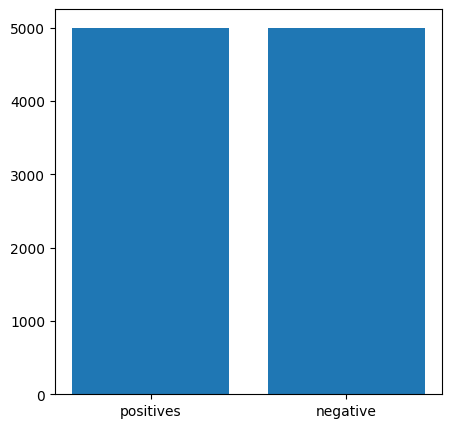

In [ ]:
fig = plt.figure(figsize=(5,5))
labels = ['positives','negative']
sizes = [y_positive,y_negative]
plt.bar(labels,sizes)
plt.show()


##1 preprocessing

In [ ]:
tweet1=all_tweets.iloc[1000]
tweet1["Tweets"]

"@seanactual You mean you're not offering? :("

##import library

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [ ]:
tweet2 = re.sub(r'RT[\s]+','',tweet1["Tweets"])

tweets2 = re.sub(r'https?://[^\s\n\r]+','',tweet2)

tweet2 = re.sub(r'#','',tweet2)

tweet2 = re.sub(r'@\w+','',tweet2)
tweet2 = re.sub(f'[:)|(:]','',tweet2)
print(tweet1["Tweets"])
print("\nCleaned Tweet: \n",tweet2)

@seanactual You mean you're not offering? :(

Cleaned Tweet: 
  You mean you're not offering? 


##tokenization

In [ ]:
tokenizer = TweetTokenizer(preserve_case=False,strip_handles=True,reduce_len=True)
tweet_tokens = tokenizer.tokenize(tweet2)
print()
print('Tokenized string:\n')
print(tweet_tokens)


Tokenized string:

['you', 'mean', "you're", 'not', 'offering', '?']


##remove stopwords and punction

In [ ]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stopwords_english = stopwords.words('english')
print('Stop words\n')
print(stopwords_english)

print('\npunctuation\n')
print(string.punctuation)

Stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

In [ ]:
print("owais,231A057\n")
print(tweet_tokens)
print()

tweet_clean = []

for word in tweet_tokens:
  if(word not in stopwords_english and word not in string.punctuation):
    tweet_clean.append(word)

print('removed stop words and punctuation:')
print(tweet_clean)

owais,231A057

['you', 'mean', "you're", 'not', 'offering', '?']

removed stop words and punctuation:
['mean', 'offering']


In [ ]:
def process_tweet(tweet):
    tokenizer = TweetTokenizer(
        preserve_case=False,
        strip_handles=True,
        reduce_len=True
    )

    # remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+', '', tweet)

    # remove hyperlinks
    tweet = re.sub(r'https?:\/\/[^\s\n\r]+', '', tweet)

    # remove the hash # sign from the word
    tweet = re.sub(r'#', '', tweet)

    # remove punctuation/special characters
    tweet = re.sub(r'@\w*;', '', tweet)
    tweet = re.sub(r'[:)|(:]', '', tweet)

    # tokenize tweets
    tweet_tokens = tokenizer.tokenize(tweet)
    stopwords_english = stopwords.words('english')
    tweets_clean = []

    # Go through every word in your tokens list
    for word in tweet_tokens:
        # remove stopwords and punctuation
        if (word not in stopwords_english and
                word not in string.punctuation):
            tweets_clean.append(word)

    return tweets_clean



In [ ]:
tweet1=all_tweets.iloc[100]
tweet=tweet1["Tweets"]
print(process_tweet(tweet))

['。', '。', '。', '´', 'ω', '」', '∠']


In [ ]:
processed_tweets=all_tweets['Tweets'].apply(process_tweet)
all_tweets['tweets_processed']=processed_tweets
pd.set_option('display.max_colwidth',None)
all_tweets

,Tweets,tweets_processed
0,hopeless for tmr :(,"[hopeless, tmr]"
1,Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(,"[everything, kids, section, ikea, cute, shame, nearly, 19, 2, months]"
2,@Hegelbon That heart sliding into the waste basket. :(,"[heart, sliding, waste, basket]"
3,"“@ketchBurning: I hate Japanese call him ""bani"" :( :(”\n\nMe too","[“, hate, japanese, call, bani, ”]"
4,"Dang starting next week I have ""work"" :(","[dang, starting, next, week, work]"
...,...,...
29995,"RT @UKLabour: .@Ed_Miliband: we're not going to do a deal with the SNP, there will be no coalition with the SNP. #bbcqt\nhttps://t.co/n65hTe…","[going, deal, snp, coalition, snp, bbcqt]"
29996,"RT @DisabledScot: @blairmcdougall @ScotlandTonight @bbcqt If Ed thinks Scots will suddenly rush to vote Labour, we'll vote SNP, Labour just…","[ed, thinks, scots, suddenly, rush, vote, labour, vote, snp, labour, …]"
29997,RT @Staircase2: @VividRicky exactly but that alleged commute was made up by Farage as was his 'discomfort' in allegedly 'not hearing Englis…,"[exactly, alleged, commute, made, farage, discomfort, allegedly, hearing, englis, …]"
29998,Actually agreed with %95 of what farage was sayin rhen#voteukip,"[actually, agreed, 95, farage, sayin, rhenvoteukip]"


In [ ]:
tweets['Tweets_processed'] = tweets['Tweets'].apply(process_tweet)
display(tweets[['Tweets_processed','sentiments']])

,Tweets_processed,sentiments
0,"[can't, sleep, need, try, lay, bed, bored]",positive
1,"[tha, case, trion, interactions, forums, twitch]",positive
2,"[ohmygod, worst, case, scenario, na, tooo]",negative
3,"[actually, would, beg, differ, one, sometimes, less, philosophical]",positive
4,"[worst, pain]",negative
...,...,...
9995,"[thank, taking, time, tweet, us, annabel, pass, london, bridge, team]",positive
9996,"[thanks, follow, great, day]",positive
9997,"[yum, feed, 6, leftovers]",negative
9998,"[jgh, bonding, niggs]",positive
